In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

2026-06-09 10:38:57.709730: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781001537.879638     831 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781001537.932370     831 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781001538.349179     831 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781001538.349210     831 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781001538.349213     831 computation_placer.cc:177] computation placer alr

In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [3]:
IMG_SIZE = 96

x_train = tf.image.resize(
    x_train,
    (IMG_SIZE, IMG_SIZE)
)

x_test = tf.image.resize(
    x_test,
    (IMG_SIZE, IMG_SIZE)
)

x_train = x_train.numpy()
x_test = x_test.numpy()

print(x_train.shape)
print(x_test.shape)

I0000 00:00:1781001550.479403     831 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781001550.485252     831 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


(50000, 96, 96, 3)
(10000, 96, 96, 3)


In [4]:
#loss function
import tensorflow as tf

class CustomLoss(tf.keras.losses.Loss):

    def __init__(
        self,
        lam=0.1,
        name="edge_aware_margin_loss"
    ):
        super().__init__(name=name)
        self.lam = lam

    def call(
        self,
        y_true,
        y_pred
    ):

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0
        )

        ce = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred
        )

        top2 = tf.math.top_k(
            y_pred,
            k=2
        ).values

        p1 = top2[:,0]
        p2 = top2[:,1]

        margin = p1 - p2

        margin_penalty = 1.0 - margin

        loss = ce + self.lam * margin_penalty

        return tf.reduce_mean(loss)

In [5]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=CustomLoss(
        lam=0.1
    ),
    metrics=['accuracy']
)

In [7]:
history1 = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("Evaluating Before Fine-Tuning...")

loss_before, acc_before = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy Before Fine-Tuning: {acc_before:.4f}")
print(f"Test Loss Before Fine-Tuning: {loss_before:.4f}")


Epoch 1/5


I0000 00:00:1781001577.066692     874 service.cc:152] XLA service 0x7dc4040426d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781001577.066745     874 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781001577.066752     874 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781001578.068610     874 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-09 10:39:46.336854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:39:46.475313: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1781001588.851695     874 device_co

351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5430 - loss: 1.4206

2026-06-09 10:40:04.634518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:40:04.771412: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5433 - loss: 1.4196

2026-06-09 10:40:20.599038: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:40:20.755856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:40:20.890749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.6571 - loss: 1.0569 - val_accuracy: 0.7644 - val_loss: 0.6986
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7518 - loss: 0.7578 - val_accuracy: 0.7834 - val_loss: 0.6471
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7672 - loss: 0.7087 - val_accuracy: 0.7928 - val_loss: 0.6281
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7728 - loss: 0.6856 - val_accuracy: 0.7976 - val_loss: 0.6191
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7782 - loss: 0.6716 - val_accuracy: 0.8026 - val_loss: 0.6064
Evaluating Before Fine-Tuning...


2026-06-09 10:41:08.443843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:41:08.586917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:41:20.073769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 10:41:20.209763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Test Accuracy Before Fine-Tuning: 0.7930
Test Loss Before Fine-Tuning: 0.6184


In [8]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=CustomLoss(
        lam=0.1
    ),
    metrics=['accuracy']
)

history2 = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
print("Evaluating After Fine-Tuning...")

loss_after, acc_after = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy After Fine-Tuning: {acc_after:.4f}")
print(f"Test Loss After Fine-Tuning: {loss_after:.4f}")

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.7360 - loss: 0.9645 - val_accuracy: 0.7764 - val_loss: 0.7079
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.8350 - loss: 0.5699 - val_accuracy: 0.8132 - val_loss: 0.5985
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.8650 - loss: 0.4481 - val_accuracy: 0.8328 - val_loss: 0.5302
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.8903 - loss: 0.3566 - val_accuracy: 0.8438 - val_loss: 0.4778
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.9046 - loss: 0.3033 - val_accuracy: 0.8706 - val_loss: 0.4110
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.9180 - loss: 0.2588 - val_accuracy: 0.8828 - val_loss: 0.3940
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.9286 - loss: 0.2193 - val_accuracy: 0.8918 - val_loss: 0.3733
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.9377 - loss: 0.1922 

In [9]:
improvement = (acc_after - acc_before) * 100

print(f"Accuracy Improvement: {improvement:.2f}%")

Accuracy Improvement: 11.53%


In [10]:
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

y_pred = model.predict(x_test)

y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
Precision: 0.9086010417374407
Recall: 0.9082999999999999
F1 Score: 0.908257874488126


In [11]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.93      0.90      0.91      1000
  automobile       0.97      0.92      0.94      1000
        bird       0.89      0.92      0.90      1000
         cat       0.83      0.82      0.82      1000
        deer       0.89      0.89      0.89      1000
         dog       0.87      0.86      0.87      1000
        frog       0.91      0.95      0.93      1000
       horse       0.94      0.92      0.93      1000
        ship       0.94      0.94      0.94      1000
       truck       0.92      0.95      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



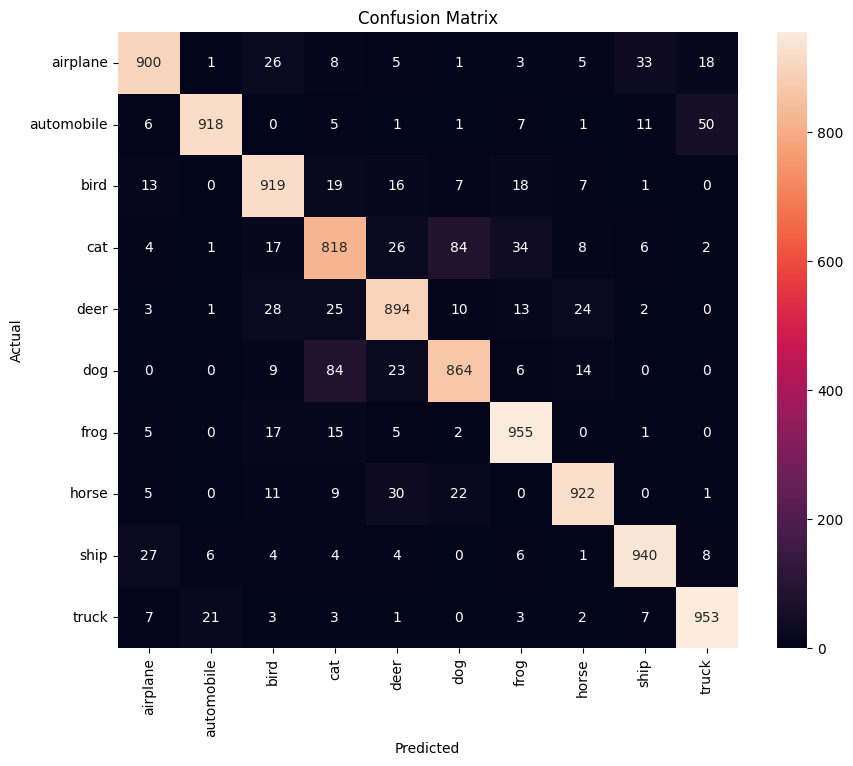

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true_labels,
    y_pred_labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

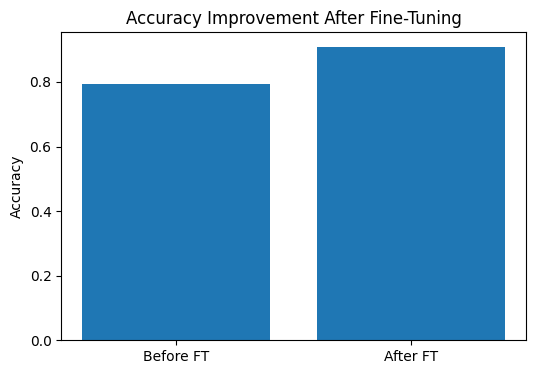

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Before FT", "After FT"],
    [acc_before, acc_after]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Improvement After Fine-Tuning")

plt.show()

In [14]:
model.save("mobilenetv2_cifar10.h5")

import os

size=os.path.getsize(
    "mobilenetv2_cifar10.h5"
)/(1024*1024)

print("Model Size:",size,"MB")

Model Size: 26.388038635253906 MB
